In [16]:
# K-means Clustering on 2D Data (2 Clusters)

## Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import time


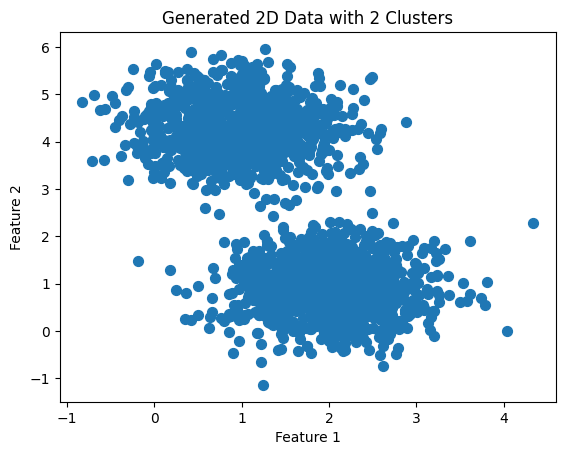

In [17]:

## Step 2: Generate 2D Data with 2 Clusters
X, y_true = make_blobs(n_samples=2000, centers=2, cluster_std=0.60, random_state=0)

plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Generated 2D Data with 2 Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


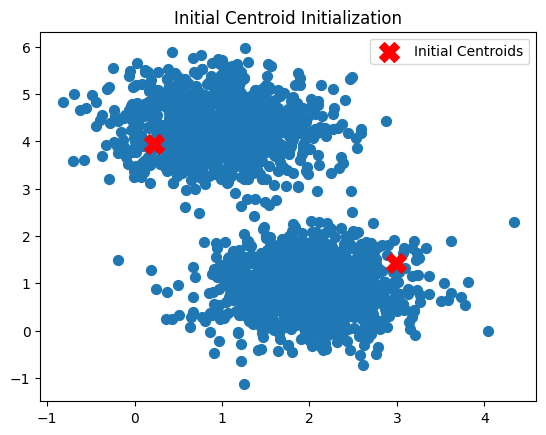

In [18]:

## Step 3: Initialize Centroids

def initialize_centroids(X, k):
    np.random.seed(42)
    indices = np.random.choice(len(X), size=k, replace=False)
    return X[indices]

k = 2
centroids = initialize_centroids(X, k)

plt.scatter(X[:, 0], X[:, 1], s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Initial Centroids')
plt.title("Initial Centroid Initialization")
plt.legend()
plt.show()


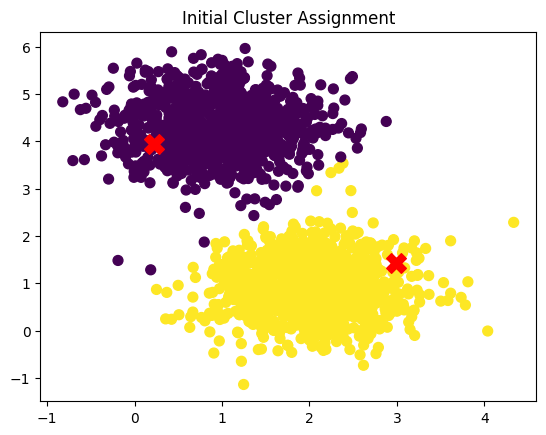

In [19]:

## Step 4: Assign Clusters

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

labels = assign_clusters(X, centroids)

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X')
plt.title("Initial Cluster Assignment")
plt.show()


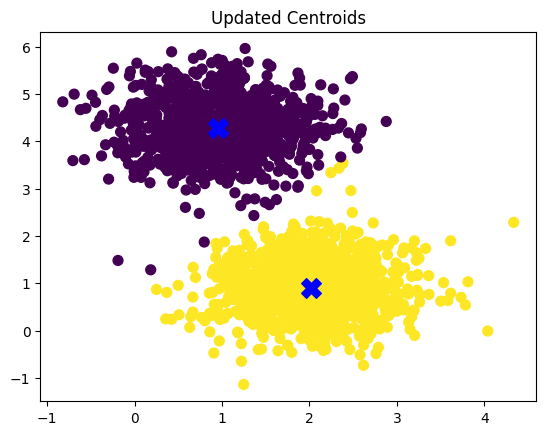

In [20]:

## Step 5: Update Centroids

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

centroids = update_centroids(X, labels, k)

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='blue', s=200, marker='X')
plt.title("Updated Centroids")
plt.show()


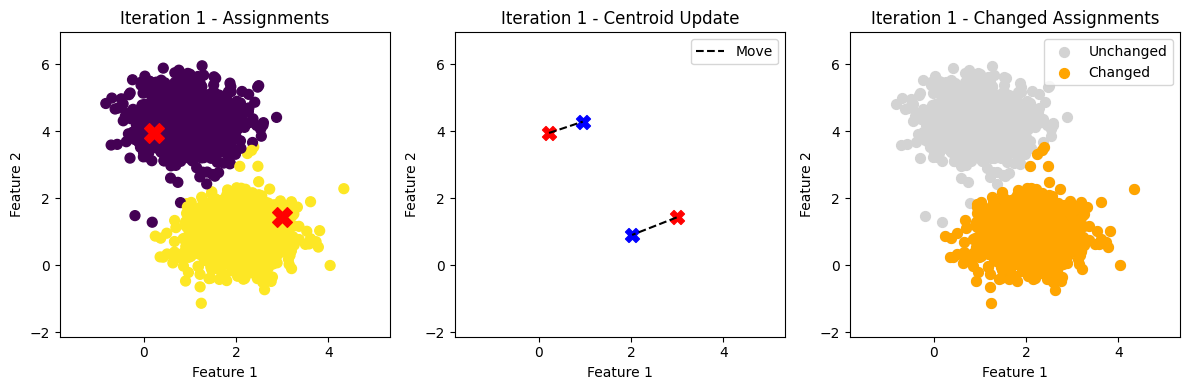

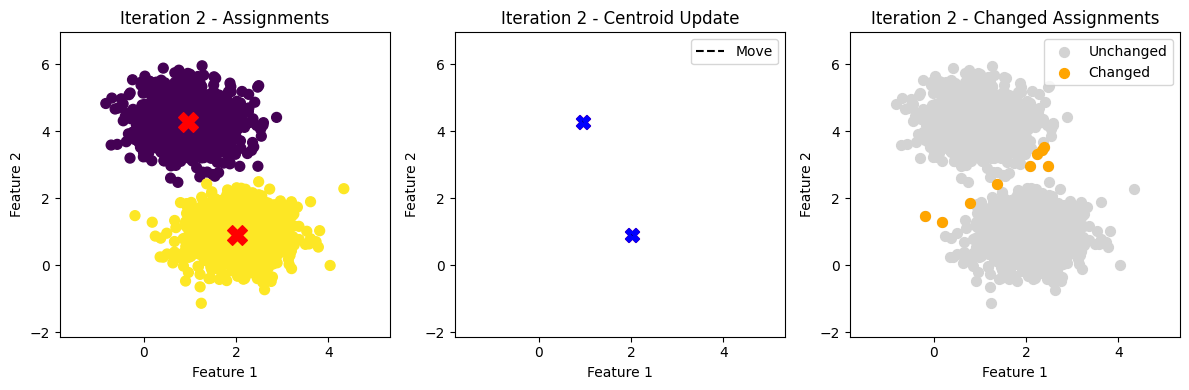

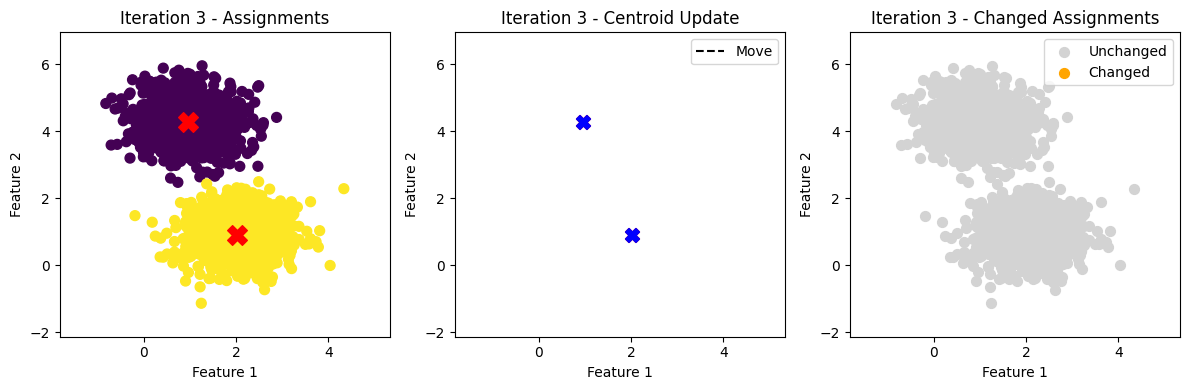

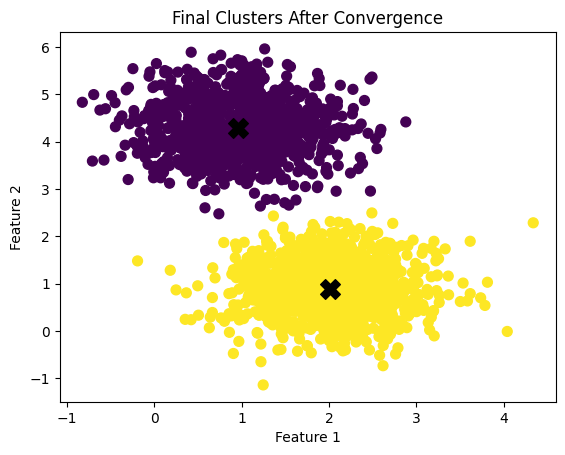

In [23]:
## Step 6: Iterate Until Convergence with Visualization

def k_means_visual(X, k, max_iters=10, tol=1e-4):
    centroids = initialize_centroids(X, k)
    xlim = [X[:, 0].min() - 1, X[:, 0].max() + 1]
    ylim = [X[:, 1].min() - 1, X[:, 1].max() + 1]

    previous_labels = np.zeros(X.shape[0])

    for i in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        plt.figure(figsize=(12, 4))

        # Subplot 1: Data point assignments
        plt.subplot(1, 3, 1)
        plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
        plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X')
        plt.title(f"Iteration {i + 1} - Assignments")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.xlim(xlim)
        plt.ylim(ylim)

        # Subplot 2: Centroid movements
        plt.subplot(1, 3, 2)
        for j in range(k):
            plt.plot([centroids[j][0], new_centroids[j][0]],
                     [centroids[j][1], new_centroids[j][1]], 'k--', label='Move' if j==0 else "")
            plt.scatter(*centroids[j], c='red', s=100, marker='X')
            plt.scatter(*new_centroids[j], c='blue', s=100, marker='X')
        plt.title(f"Iteration {i + 1} - Centroid Update")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.legend()

        # Subplot 3: Highlight changed assignments
        changed = labels != previous_labels
        plt.subplot(1, 3, 3)
        plt.scatter(X[:, 0], X[:, 1], c='lightgray', s=50, label='Unchanged')
        plt.scatter(X[changed, 0], X[changed, 1], c='orange', s=50, label='Changed')
        plt.title(f"Iteration {i + 1} - Changed Assignments")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.legend()

        plt.tight_layout()
        plt.show()
        time.sleep(2)  # pause for viewers

        if np.all(np.abs(new_centroids - centroids) < tol):
            break

        centroids = new_centroids
        previous_labels = labels.copy()

    return centroids, labels

final_centroids, final_labels = k_means_visual(X, k)

plt.scatter(X[:, 0], X[:, 1], c=final_labels, s=50, cmap='viridis')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='black', s=200, marker='X')
plt.title("Final Clusters After Convergence")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
